In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.listdir('/content/drive/MyDrive/Colab')

['placement_dataset.csv',
 'placement_predict_50k_adjusted.csv',
 'age_insurance.csv',
 'placement_predict_50k Dataset (1).csv',
 'WineQT.csv',
 'weather_cricket.csv']

In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab/WineQT.csv')

In [ ]:
# Select only chemical properties for anomaly detection

features = [
    'fixed acidity',
    'volatile acidity',
    'citric acid',
    'residual sugar',
    'chlorides',
    'free sulfur dioxide',
    'total sulfur dioxide',
    'density',
    'pH',
    'sulphates',
    'alcohol'
]

X = df[features]

print("Number of samples:", X.shape[0])
print("Number of chemical features:", X.shape[1])
print("\nFeatures used:")
print(features)

Number of samples: 1143
Number of chemical features: 11

Features used:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Original shape:", X.shape)
print("Scaled shape:", X_scaled.shape)

Original shape: (1143, 11)
Scaled shape: (1143, 11)


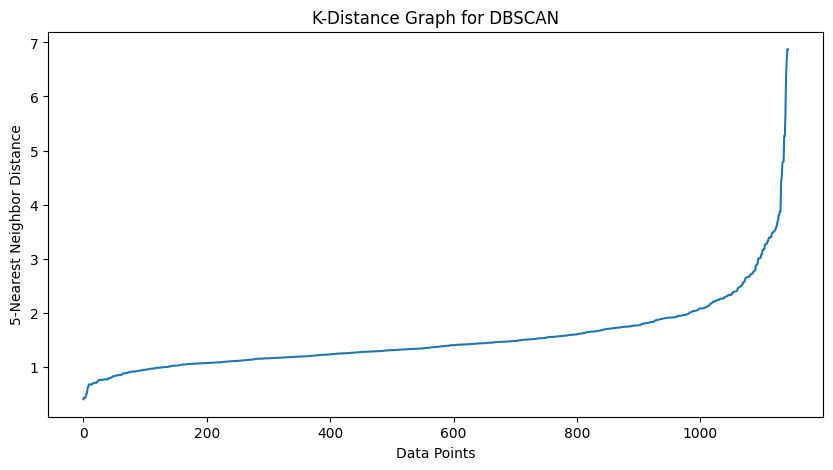

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

min_samples = 5

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(X_scaled)

distances, indices = neighbors.kneighbors(X_scaled)

k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 5))
plt.plot(k_distances)

plt.xlabel("Data Points")
plt.ylabel("5-Nearest Neighbor Distance")
plt.title("K-Distance Graph for DBSCAN")

plt.show()

In [ ]:
from sklearn.cluster import DBSCAN
import numpy as np

# Baseline DBSCAN
eps_value = 2.5
min_samples = 5

dbscan = DBSCAN(
    eps=eps_value,
    min_samples=min_samples
)

labels = dbscan.fit_predict(X_scaled)

# Add DBSCAN result to dataframe
df['DBSCAN_Cluster'] = labels

# Count clusters and noise points
unique_labels, counts = np.unique(labels, return_counts=True)

print("DBSCAN Results")
print("----------------")

for label, count in zip(unique_labels, counts):
    if label == -1:
        print(f"Noise (-1): {count} samples")
    else:
        print(f"Cluster {label}: {count} samples")

noise_count = np.sum(labels == -1)
cluster_count = len(set(labels)) - (1 if -1 in labels else 0)

print("\nNumber of clusters:", cluster_count)
print("Number of candidate anomalies:", noise_count)
print("Noise percentage:", round((noise_count / len(labels)) * 100, 2), "%")

DBSCAN Results
----------------
Noise (-1): 55 samples
Cluster 0: 1079 samples
Cluster 1: 9 samples

Number of clusters: 2
Number of candidate anomalies: 55
Noise percentage: 4.81 %


In [ ]:
# Inspect the small DBSCAN cluster

small_cluster = df[df['DBSCAN_Cluster'] == 1]

print("Number of samples in Cluster 1:", len(small_cluster))
print("\nCluster 1 samples:")
display(small_cluster)

Number of samples in Cluster 1: 9

Cluster 1 samples:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,DBSCAN_Cluster
13,7.9,0.320,0.51,1.8,0.341,17.0,56.0,0.99690,3.04,1.08,9.2,6,19,1
75,7.8,0.410,0.68,1.7,0.467,18.0,69.0,0.99730,3.08,1.31,9.3,5,106,1
490,8.6,0.490,0.51,2.0,0.422,16.0,62.0,0.99790,3.03,1.17,9.0,5,692,1
538,7.8,0.480,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.1,6,754,1
738,8.5,0.460,0.59,1.4,0.414,16.0,45.0,0.99702,3.03,1.34,9.2,5,1051,1
890,8.6,0.635,0.68,1.8,0.403,19.0,56.0,0.99632,3.02,1.15,9.3,5,1260,1
934,9.1,0.760,0.68,1.7,0.414,18.0,64.0,0.99652,2.90,1.33,9.1,6,1319,1
973,8.7,0.780,0.51,1.7,0.415,12.0,66.0,0.99623,3.00,1.17,9.2,5,1370,1
975,8.7,0.780,0.51,1.7,0.415,12.0,66.0,0.99623,3.00,1.17,9.2,5,1372,1


In [ ]:
# Compare cluster sizes

cluster_sizes = (
    df[df['DBSCAN_Cluster'] != -1]
    ['DBSCAN_Cluster']
    .value_counts()
    .sort_index()
)

print("Cluster sizes:")
print(cluster_sizes)

Cluster sizes:
DBSCAN_Cluster
0    1079
1       9
Name: count, dtype: int64


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

print(os.getcwd())
print(os.listdir('/content'))

/content
['.config', 'drive', 'sample_data']


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving WineQT.csv to WineQT.csv


In [ ]:
import pandas as pd

df = pd.read_csv('WineQT.csv')

print("Dataset shape:", df.shape)

Dataset shape: (1143, 13)


In [ ]:
features = [
    'fixed acidity',
    'volatile acidity',
    'citric acid',
    'residual sugar',
    'chlorides',
    'free sulfur dioxide',
    'total sulfur dioxide',
    'density',
    'pH',
    'sulphates',
    'alcohol'
]

X = df[features]

print("Feature shape:", X.shape)

Feature shape: (1143, 11)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled shape:", X_scaled.shape)

Scaled shape: (1143, 11)


In [ ]:
from sklearn.cluster import DBSCAN
import numpy as np

eps_value = 2.5
min_samples = 5

dbscan = DBSCAN(
    eps=eps_value,
    min_samples=min_samples
)

labels = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = labels

unique_labels, counts = np.unique(labels, return_counts=True)

for label, count in zip(unique_labels, counts):
    if label == -1:
        print(f"Noise (-1): {count} samples")
    else:
        print(f"Cluster {label}: {count} samples")

noise_count = np.sum(labels == -1)
cluster_count = len(set(labels)) - (1 if -1 in labels else 0)

print("\nNumber of clusters:", cluster_count)
print("Number of candidate anomalies:", noise_count)
print("Noise percentage:", round((noise_count / len(labels)) * 100, 2), "%")

Noise (-1): 55 samples
Cluster 0: 1079 samples
Cluster 1: 9 samples

Number of clusters: 2
Number of candidate anomalies: 55
Noise percentage: 4.81 %


Explained variance ratio: [0.28692345 0.17075104]
Total explained variance: 0.4577


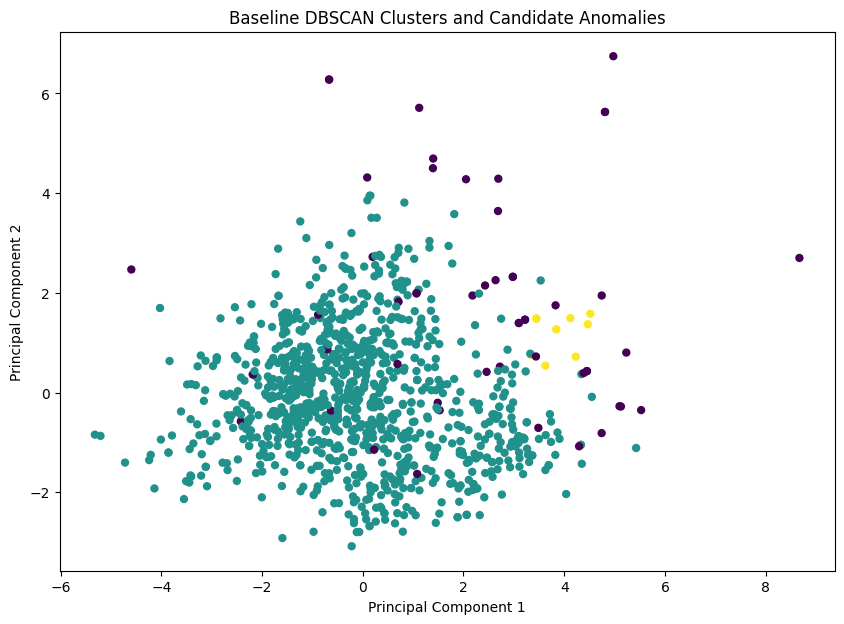

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Apply PCA to reduce 11 dimensions to 2 dimensions
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# Explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)

print(
    "Total explained variance:",
    round(pca.explained_variance_ratio_.sum(), 4)
)

# PCA visualization of DBSCAN results
plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels,
    s=25
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Baseline DBSCAN Clusters and Candidate Anomalies")

plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

features = [
    'fixed acidity',
    'volatile acidity',
    'citric acid',
    'residual sugar',
    'chlorides',
    'free sulfur dioxide',
    'total sulfur dioxide',
    'density',
    'pH',
    'sulphates',
    'alcohol'
]

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature shape:", X.shape)
print("Scaled shape:", X_scaled.shape)

Feature shape: (1143, 11)
Scaled shape: (1143, 11)


In [ ]:
from sklearn.cluster import DBSCAN
import numpy as np
import pandas as pd

eps_values = [2.0, 2.2, 2.4, 2.5, 2.6, 2.8, 3.0]
min_samples_values = [4, 5, 6, 7, 8, 10]

results = []

for eps in eps_values:
    for min_samples in min_samples_values:

        model = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels_temp = model.fit_predict(X_scaled)

        noise_count = np.sum(labels_temp == -1)

        cluster_count = len(set(labels_temp))

        if -1 in labels_temp:
            cluster_count -= 1

        results.append({
            "eps": eps,
            "min_samples": min_samples,
            "clusters": cluster_count,
            "candidate_anomalies": noise_count,
            "noise_percentage": round(
                (noise_count / len(labels_temp)) * 100, 2
            )
        })

results_df = pd.DataFrame(results)

results_df

,eps,min_samples,clusters,candidate_anomalies,noise_percentage
0,2.0,4,4,94,8.22
1,2.0,5,4,100,8.75
2,2.0,6,3,112,9.80
3,2.0,7,2,120,10.50
4,2.0,8,1,133,11.64
5,2.0,10,2,138,12.07
6,2.2,4,4,71,6.21
7,2.2,5,3,79,6.91
8,2.2,6,2,89,7.79
9,2.2,7,2,92,8.05


In [ ]:
# Calculate cluster sizes

cluster_sizes = df['DBSCAN_Cluster'].value_counts().sort_index()

print("Cluster sizes:\n")
print(cluster_sizes)

print("\nCluster percentages:\n")

for cluster, size in cluster_sizes.items():
    percentage = (size / len(df)) * 100

    if cluster == -1:
        print(f"Noise (-1): {size} samples ({percentage:.2f}%)")
    else:
        print(f"Cluster {cluster}: {size} samples ({percentage:.2f}%)")

Cluster sizes:

DBSCAN_Cluster
-1      55
 0    1079
 1       9
Name: count, dtype: int64

Cluster percentages:

Noise (-1): 55 samples (4.81%)
Cluster 0: 1079 samples (94.40%)
Cluster 1: 9 samples (0.79%)


In [ ]:
# Test different small-cluster thresholds

thresholds = [0.005, 0.01, 0.02, 0.03]

n_samples = len(df)

for threshold in thresholds:

    enhanced_labels = labels.copy()

    for cluster in np.unique(enhanced_labels):

        # Skip DBSCAN noise
        if cluster == -1:
            continue

        cluster_size = np.sum(enhanced_labels == cluster)
        cluster_fraction = cluster_size / n_samples

        # Convert very small clusters into noise
        if cluster_fraction < threshold:
            enhanced_labels[enhanced_labels == cluster] = -1

    anomaly_count = np.sum(enhanced_labels == -1)
    anomaly_percentage = (anomaly_count / n_samples) * 100

    print(
        f"Threshold = {threshold*100:.1f}% | "
        f"Candidate anomalies = {anomaly_count} | "
        f"Percentage = {anomaly_percentage:.2f}%"
    )

Threshold = 0.5% | Candidate anomalies = 55 | Percentage = 4.81%
Threshold = 1.0% | Candidate anomalies = 64 | Percentage = 5.60%
Threshold = 2.0% | Candidate anomalies = 64 | Percentage = 5.60%
Threshold = 3.0% | Candidate anomalies = 64 | Percentage = 5.60%


In [ ]:
# Enhanced DBSCAN using a small-cluster threshold

cluster_threshold = 0.01   # 1%

enhanced_labels = labels.copy()

for cluster in np.unique(enhanced_labels):

    # Ignore DBSCAN noise
    if cluster == -1:
        continue

    cluster_size = np.sum(enhanced_labels == cluster)
    cluster_fraction = cluster_size / len(enhanced_labels)

    # Convert very small clusters into noise
    if cluster_fraction < cluster_threshold:
        enhanced_labels[enhanced_labels == cluster] = -1

df['Enhanced_DBSCAN_Cluster'] = enhanced_labels

# Count final clusters and candidate anomalies
unique_labels, counts = np.unique(
    enhanced_labels,
    return_counts=True
)

print("Enhanced DBSCAN Results:\n")

for label, count in zip(unique_labels, counts):

    if label == -1:
        print(f"Candidate anomalies (-1): {count} samples")
    else:
        print(f"Cluster {label}: {count} samples")

anomaly_count = np.sum(enhanced_labels == -1)

print("\nNumber of candidate anomalies:", anomaly_count)
print(
    "Candidate anomaly percentage:",
    round((anomaly_count / len(df)) * 100, 2),
    "%"
)

Enhanced DBSCAN Results:

Candidate anomalies (-1): 64 samples
Cluster 0: 1079 samples

Number of candidate anomalies: 64
Candidate anomaly percentage: 5.6 %


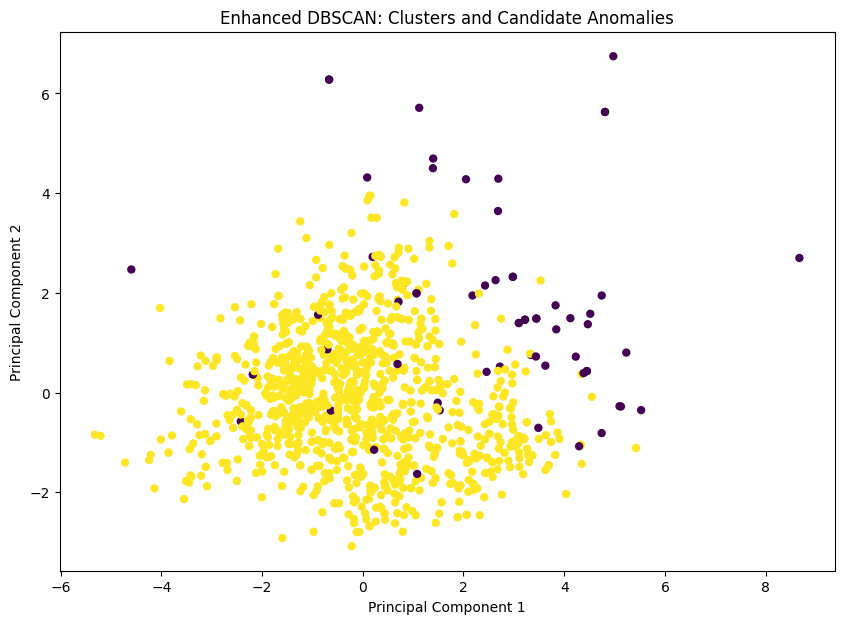

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca[:, 0], #Yellow: Cluster 0 — the main dense group of 1079 samples.
    X_pca[:, 1], #Purple: Candidate anomalies — 64 samples after the small-cluster enhancement.
    c=enhanced_labels,
    s=25
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Enhanced DBSCAN: Clusters and Candidate Anomalies")

plt.show()

In [ ]:
# Identify the 9 samples added by the enhancement

original_noise = labels == -1
enhanced_noise = enhanced_labels == -1

new_candidates = enhanced_noise & (~original_noise)

print("New candidate anomalies added by enhancement:",
      np.sum(new_candidates))

# Display their chemical properties
new_candidate_df = df.loc[new_candidates, features]

new_candidate_df

New candidate anomalies added by enhancement: 9


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
13,7.9,0.320,0.51,1.8,0.341,17.0,56.0,0.99690,3.04,1.08,9.2
75,7.8,0.410,0.68,1.7,0.467,18.0,69.0,0.99730,3.08,1.31,9.3
490,8.6,0.490,0.51,2.0,0.422,16.0,62.0,0.99790,3.03,1.17,9.0
538,7.8,0.480,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.1
738,8.5,0.460,0.59,1.4,0.414,16.0,45.0,0.99702,3.03,1.34,9.2
890,8.6,0.635,0.68,1.8,0.403,19.0,56.0,0.99632,3.02,1.15,9.3
934,9.1,0.760,0.68,1.7,0.414,18.0,64.0,0.99652,2.90,1.33,9.1
973,8.7,0.780,0.51,1.7,0.415,12.0,66.0,0.99623,3.00,1.17,9.2
975,8.7,0.780,0.51,1.7,0.415,12.0,66.0,0.99623,3.00,1.17,9.2


In [ ]:
# Compare chemical-property statistics

main_cluster = df[labels == 0][features]
original_noise_df = df[labels == -1][features]
new_candidates_df = df[new_candidates][features]

comparison = pd.DataFrame({
    "Main Cluster Mean": main_cluster.mean(),
    "Original Noise Mean": original_noise_df.mean(),
    "New Candidates Mean": new_candidates_df.mean()
})

comparison.round(3)

,Main Cluster Mean,Original Noise Mean,New Candidates Mean
fixed acidity,8.276,8.989,8.411
volatile acidity,0.532,0.513,0.568
citric acid,0.258,0.428,0.594
residual sugar,2.403,5.191,1.722
chlorides,0.081,0.142,0.412
free sulfur dioxide,15.077,26.155,15.778
total sulfur dioxide,43.617,89.127,57.333
density,0.997,0.998,0.997
pH,3.321,3.167,3.021
sulphates,0.641,0.901,1.198
